In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")

#Read The Data

In [3]:
df=pd.read_csv("data/raw.csv")

show 5 rows of Data

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Check shape

In [5]:
df.shape

(7032, 21)

check Datatypes

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [7]:
df.drop("customerID",axis=1,inplace=True)

In [8]:
df.duplicated().sum()

np.int64(22)

In [9]:
df.drop_duplicates(keep="last",inplace=True)

In [10]:
df.shape

(7010, 20)

In [11]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5869
1    1141
Name: count, dtype: int64

In [12]:
df["SeniorCitizen"]=df["SeniorCitizen"].replace({0:"NO",1:"Yes"})

In [13]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
NO     5869
Yes    1141
Name: count, dtype: int64

In [14]:
Numerical=df.select_dtypes(exclude="object")
categorical=df.select_dtypes(include="object")

In [15]:
for i in categorical:
    print(df[i].value_counts())
    print("="*100)

gender
Male      3535
Female    3475
Name: count, dtype: int64
SeniorCitizen
NO     5869
Yes    1141
Name: count, dtype: int64
Partner
No     3617
Yes    3393
Name: count, dtype: int64
Dependents
No     4911
Yes    2099
Name: count, dtype: int64
PhoneService
Yes    6330
No      680
Name: count, dtype: int64
MultipleLines
No                  3363
Yes                 2967
No phone service     680
Name: count, dtype: int64
InternetService
Fiber optic    3090
DSL            2414
No             1506
Name: count, dtype: int64
OnlineSecurity
No                     3489
Yes                    2015
No internet service    1506
Name: count, dtype: int64
OnlineBackup
No                     3079
Yes                    2425
No internet service    1506
Name: count, dtype: int64
DeviceProtection
No                     3086
Yes                    2418
No internet service    1506
Name: count, dtype: int64
TechSupport
No                     3464
Yes                    2040
No internet service    1506
Nam

In [16]:
categorical.shape

(7010, 17)

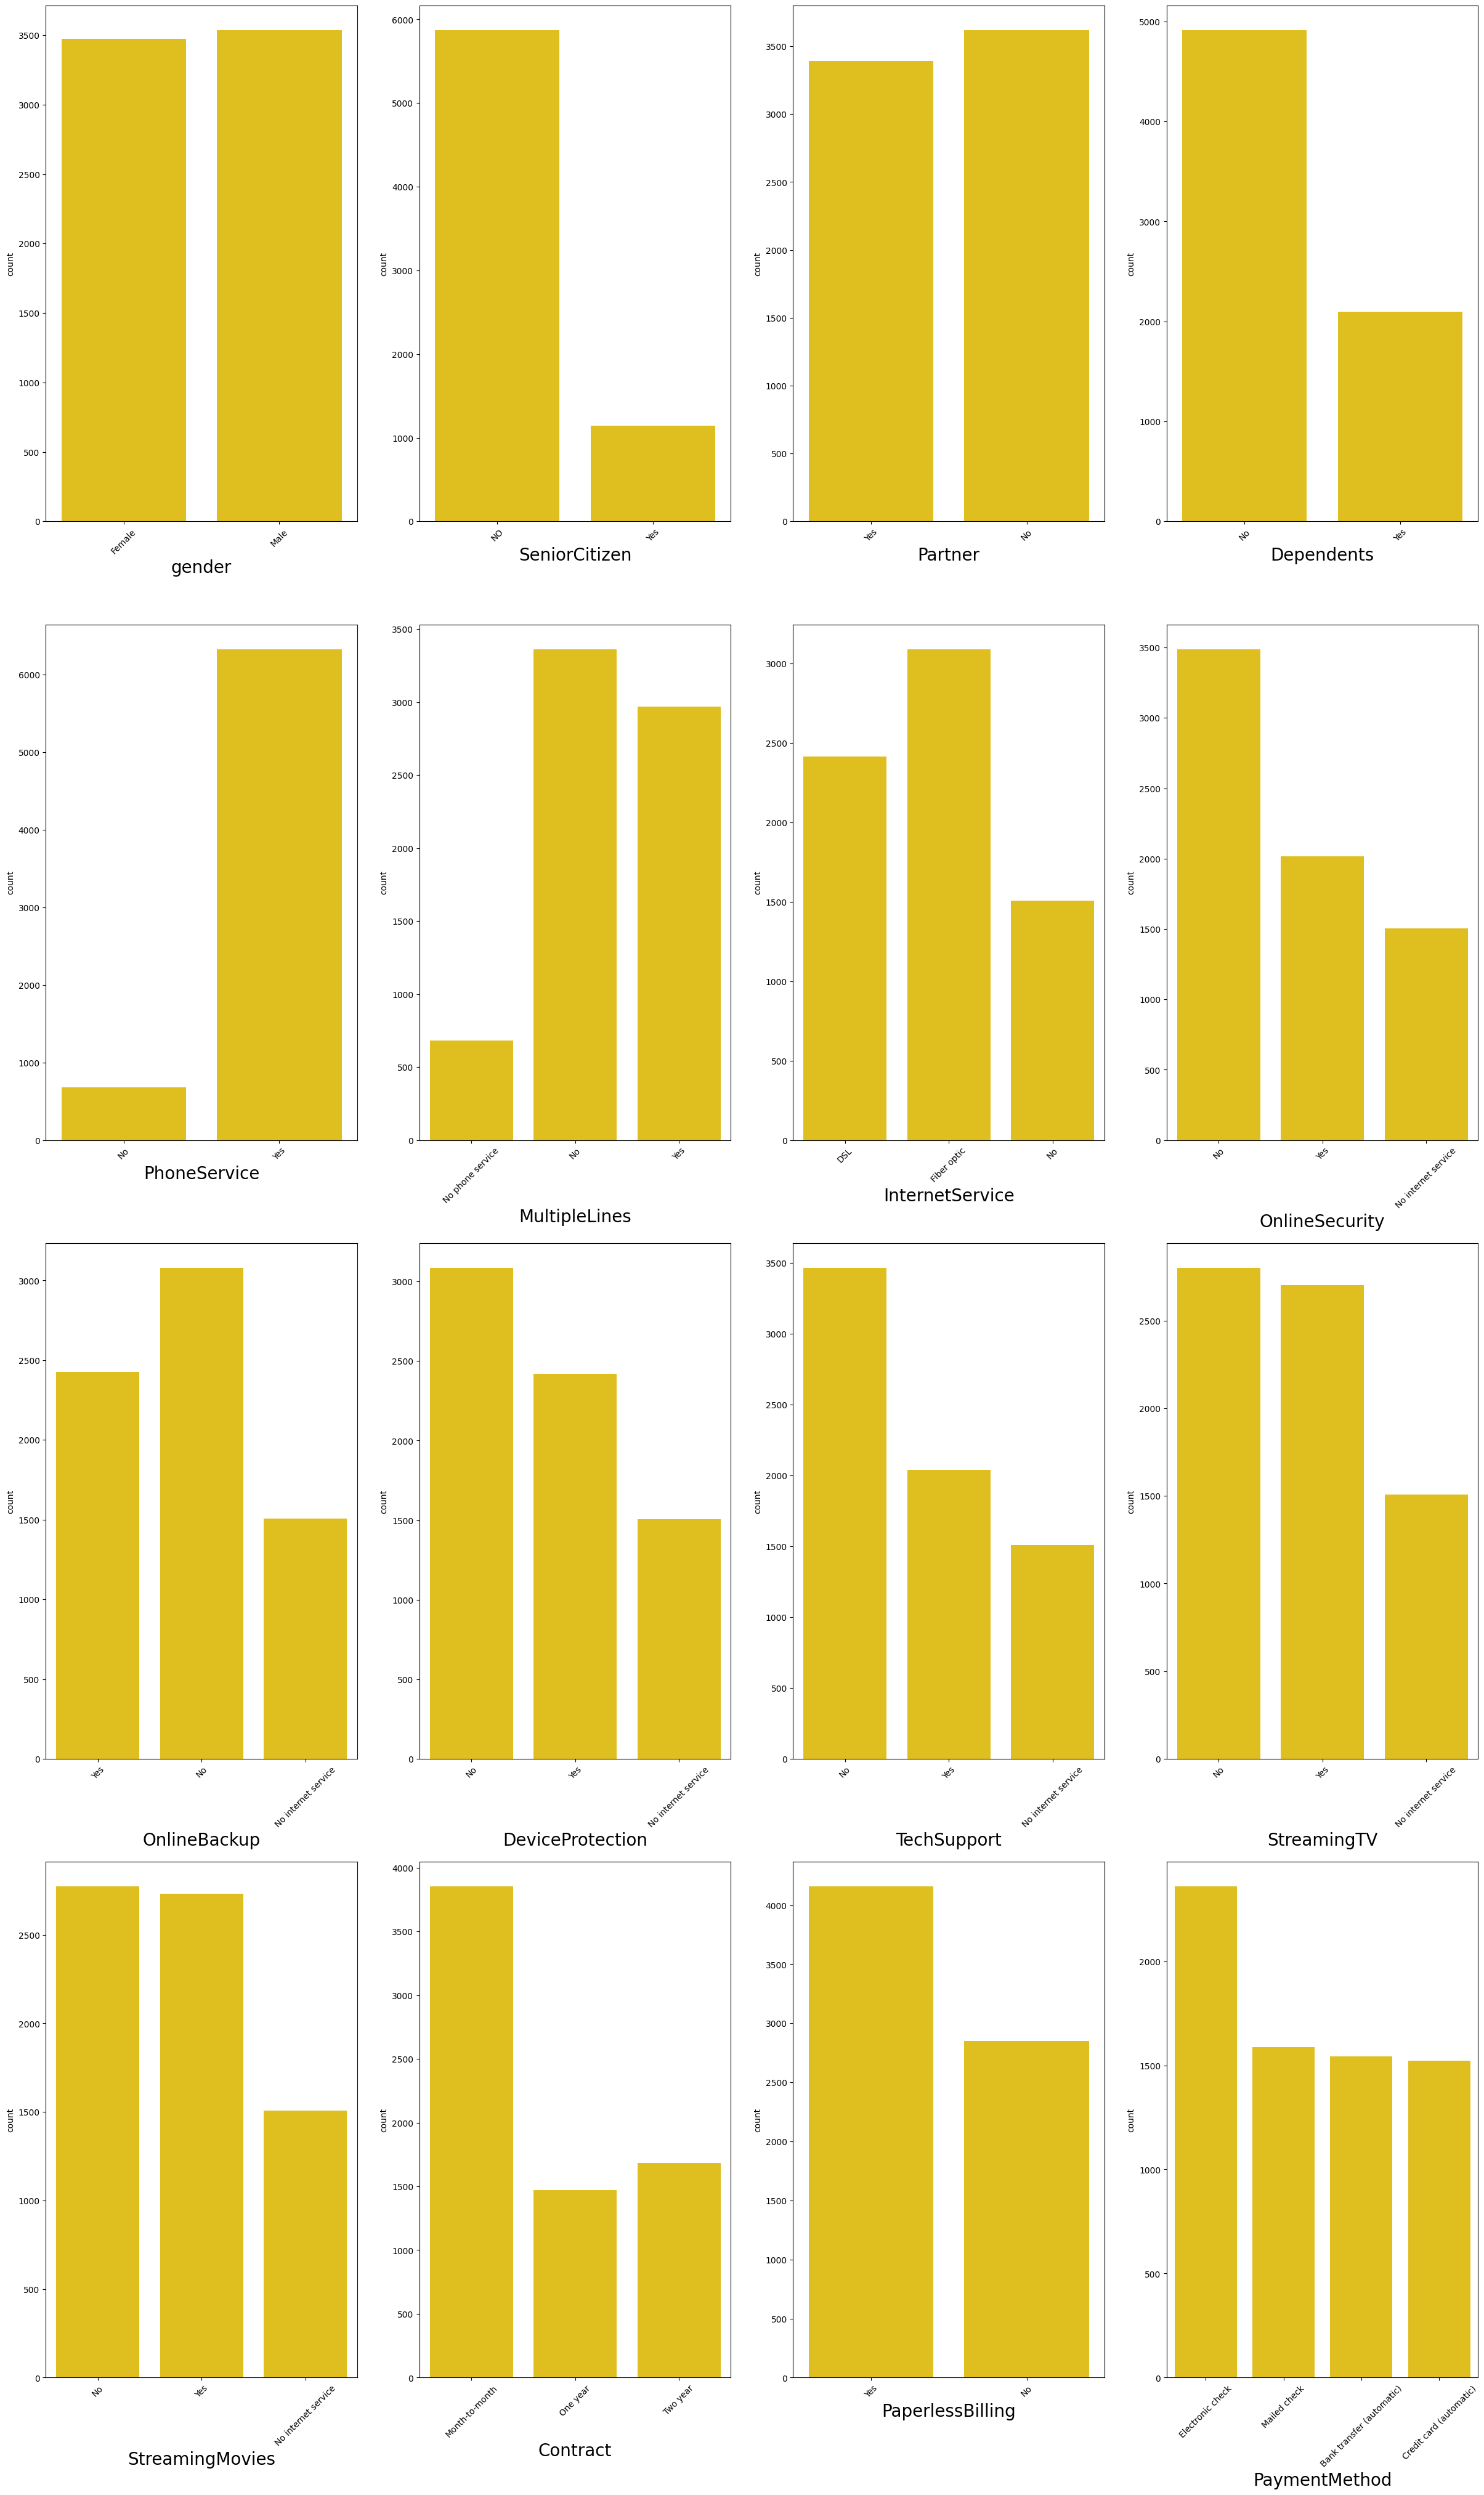

In [17]:
sns.set_palette("hsv")
plt.figure(figsize=(30,50),facecolor="white")
plotnumber=1
for i in categorical:
    if plotnumber<=16:
        ax=plt.subplot(4,4,plotnumber)
        sns.countplot(x=df[i])
        plt.xticks(rotation=45)
        plt.xlabel(i,fontsize=20)
    plotnumber=plotnumber+1
plt.show()

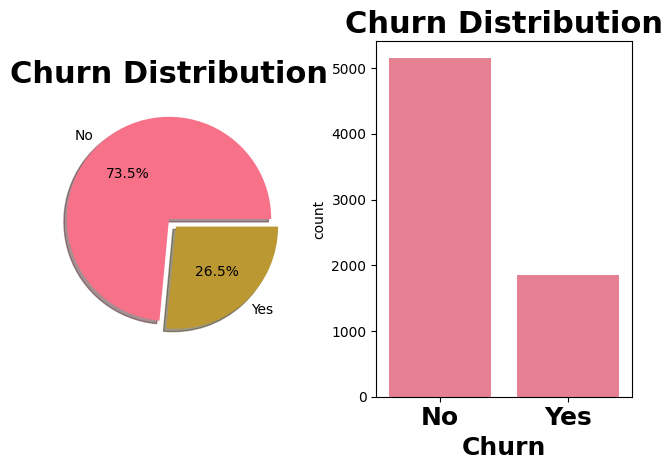

In [18]:
sns.set_palette("husl")
plt.subplot(1,2,1)
df["Churn"].value_counts().plot.pie(explode=[0,0.1],autopct="%3.1f%%",shadow=True)
plt.title("Churn Distribution",fontsize=22,fontweight="bold")
plt.ylabel(" ")
plt.subplot(1,2,2)
sns.countplot(x="Churn",data=df)
plt.title("Churn Distribution",fontsize=22,fontweight="bold")
plt.xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

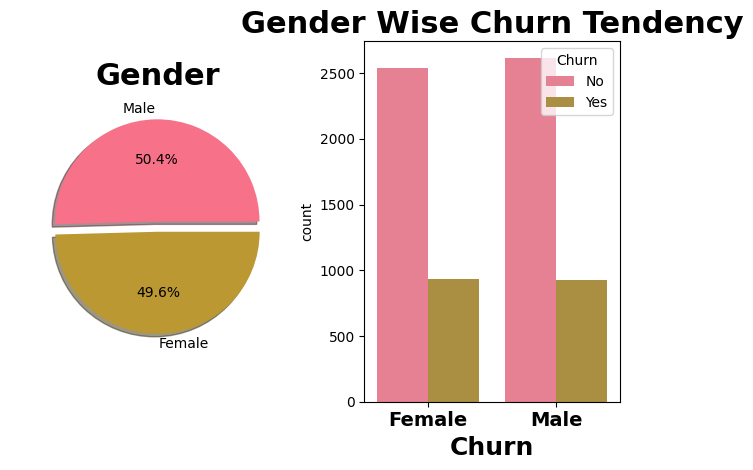

In [19]:
sns.set_palette("husl")
plt.subplot(1,2,1)
df["gender"].value_counts().plot.pie(explode=[0,0.1],autopct="%3.1f%%",shadow=True)
plt.title("Gender",fontsize=22,fontweight="bold")
plt.ylabel(" ")
plt.subplot(1,2,2)
sns.countplot(x="gender",hue="Churn",data=df)
plt.title("Gender Wise Churn Tendency",fontsize=22,fontweight="bold")
plt.xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

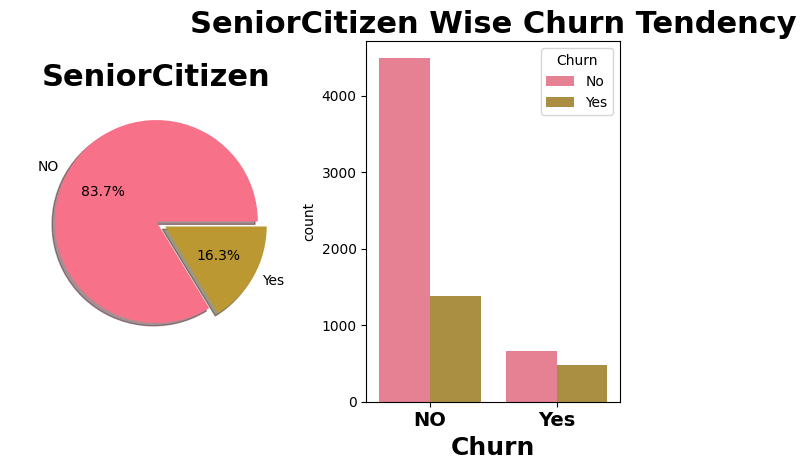

In [20]:
sns.set_palette("husl")
plt.subplot(1,2,1)
df["SeniorCitizen"].value_counts().plot.pie(explode=[0,0.1],autopct="%3.1f%%",shadow=True)
plt.title("SeniorCitizen",fontsize=22,fontweight="bold")
plt.ylabel(" ")
plt.subplot(1,2,2)
sns.countplot(x="SeniorCitizen",hue="Churn",data=df)
plt.title("SeniorCitizen Wise Churn Tendency",fontsize=22,fontweight="bold")
plt.xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

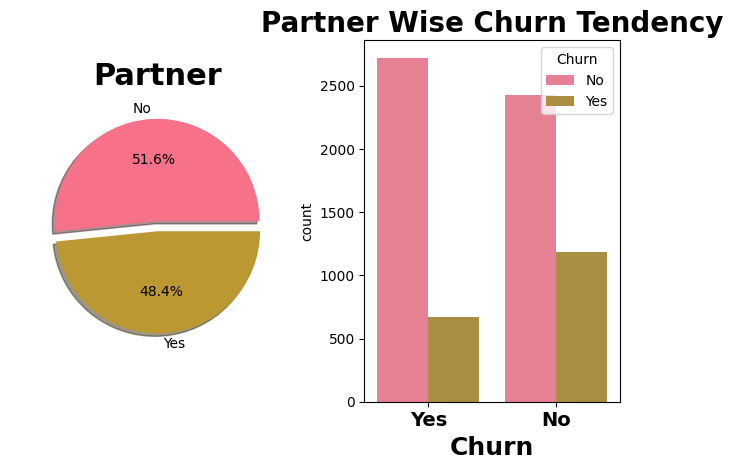

In [21]:
sns.set_palette("husl")
plt.subplot(1,2,1)
df["Partner"].value_counts().plot.pie(explode=[0,0.1],autopct="%3.1f%%",shadow=True)
plt.title("Partner",fontsize=22,fontweight="bold")
plt.ylabel(" ")
plt.subplot(1,2,2)
sns.countplot(x="Partner",hue="Churn",data=df)
plt.title("Partner Wise Churn Tendency",fontsize=20,fontweight="bold")
plt.xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

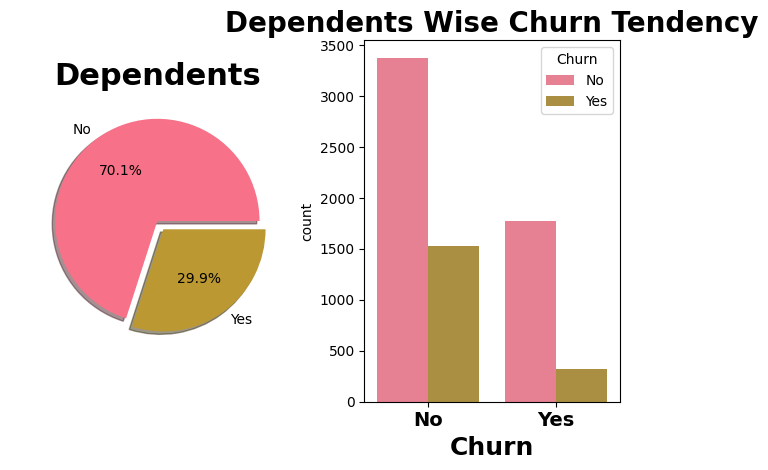

In [22]:
sns.set_palette("husl")
plt.subplot(1,2,1)
df["Dependents"].value_counts().plot.pie(explode=[0,0.1],autopct="%3.1f%%",shadow=True)
plt.title("Dependents",fontsize=22,fontweight="bold")
plt.ylabel(" ")
plt.subplot(1,2,2)
sns.countplot(x="Dependents",hue="Churn",data=df)
plt.title("Dependents Wise Churn Tendency",fontsize=20,fontweight="bold")
plt.xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

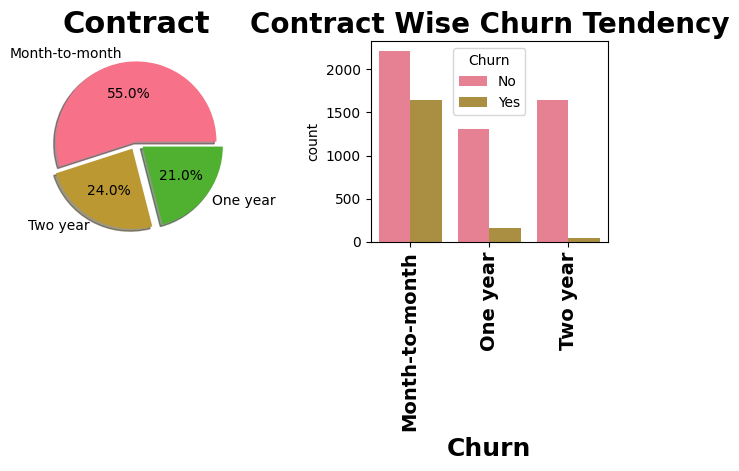

In [23]:
sns.set_palette("husl")
plt.subplot(1,2,1)
df["Contract"].value_counts().plot.pie(explode=[0,0.1,0.1],autopct="%3.1f%%",shadow=True)
plt.title("Contract",fontsize=22,fontweight="bold")
plt.ylabel(" ")
plt.subplot(1,2,2)
sns.countplot(x ="Contract",hue="Churn",data=df)
plt.title("Contract Wise Churn Tendency",fontsize=20,fontweight="bold")
plt.xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=14,fontweight="bold")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

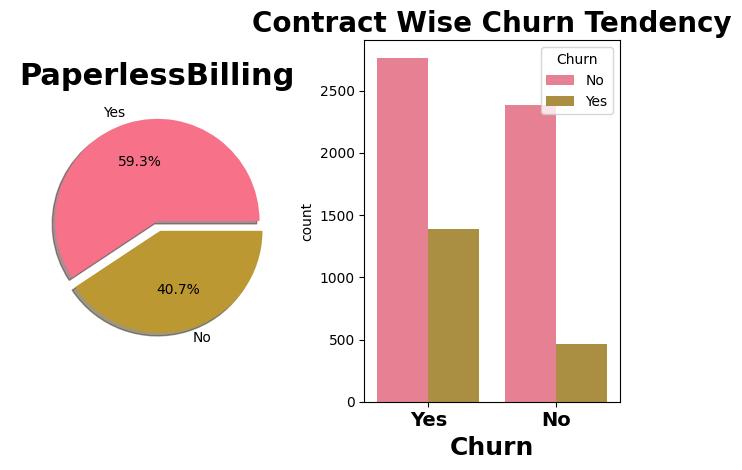

In [24]:
sns.set_palette("husl")
plt.subplot(1,2,1)
df["PaperlessBilling"].value_counts().plot.pie(explode=[0,0.1,],autopct="%3.1f%%",shadow=True)
plt.title("PaperlessBilling",fontsize=22,fontweight="bold")
plt.ylabel(" ")
plt.subplot(1,2,2)
sns.countplot(x ="PaperlessBilling",hue="Churn",data=df)
plt.title("Contract Wise Churn Tendency",fontsize=20,fontweight="bold")
plt.xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

In [25]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2359
Mailed check                 1588
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

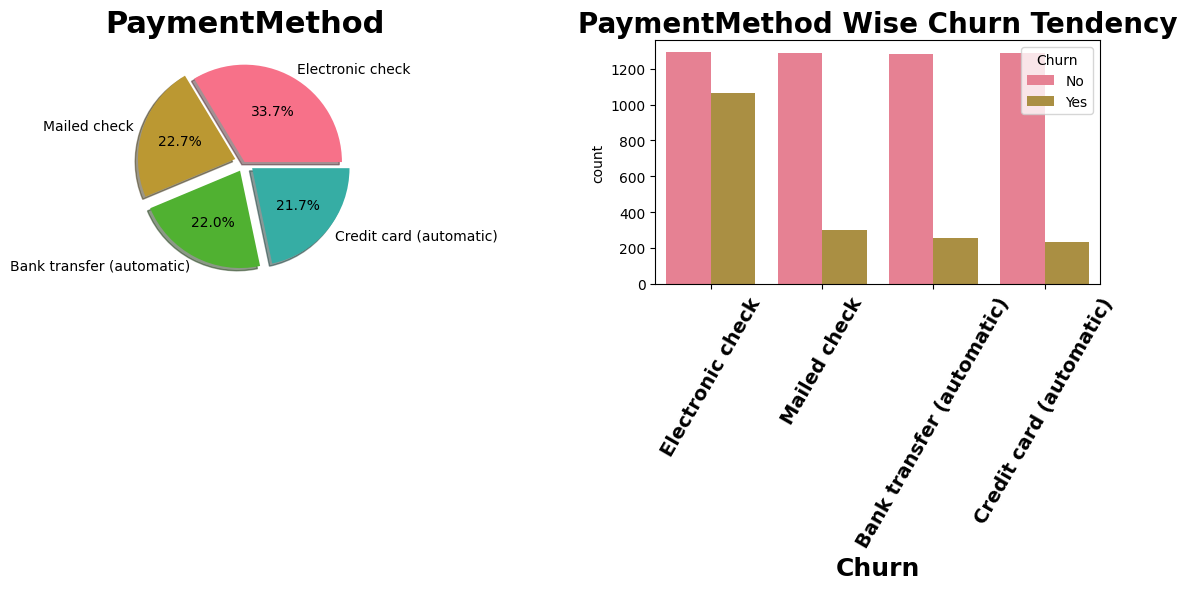

In [26]:
sns.set_palette("husl")
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
df["PaymentMethod"].value_counts().plot.pie(explode=[0,0.1,0.1,0.1],autopct="%3.1f%%",shadow=True)
plt.title("PaymentMethod",fontsize=22,fontweight="bold")
plt.ylabel(" ")
plt.subplot(1,2,2)
sns.countplot(x ="PaymentMethod",hue="Churn",data=df)
plt.title("PaymentMethod Wise Churn Tendency",fontsize=20,fontweight="bold")
plt.xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=14,fontweight="bold")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [27]:
Numerical

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
...,...,...,...
7027,24,84.80,1990.50
7028,72,103.20,7362.90
7029,11,29.60,346.45
7030,4,74.40,306.60


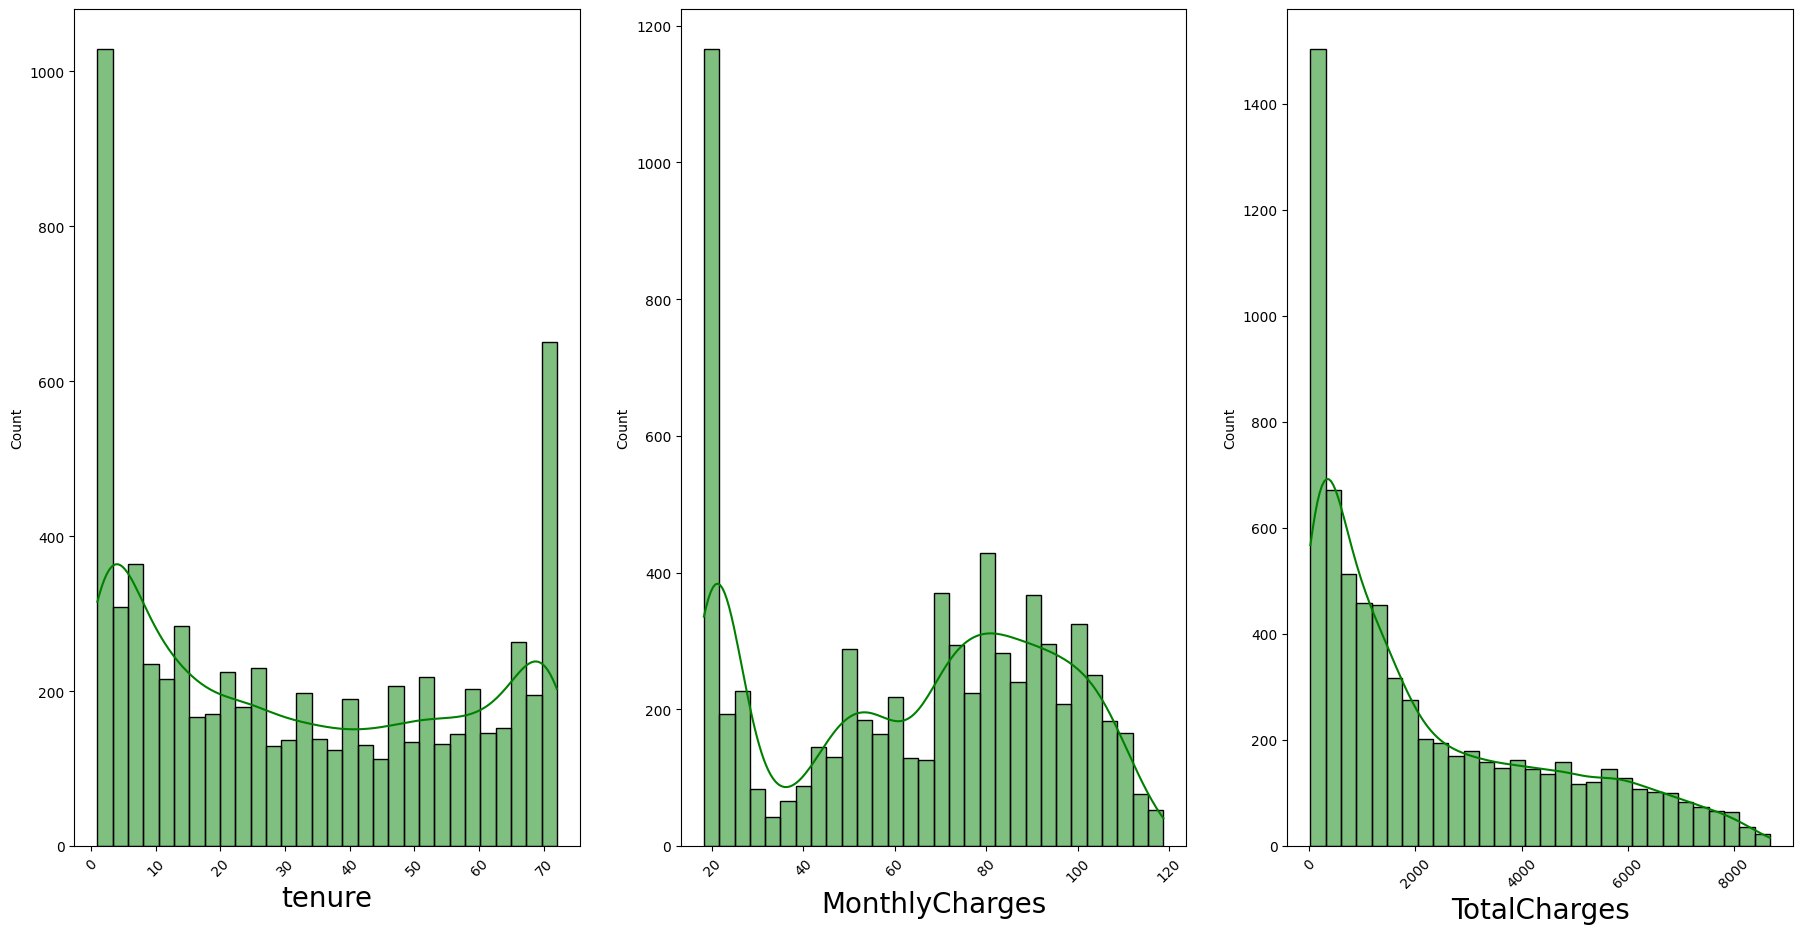

In [28]:
plt.figure(figsize=(30,50),facecolor="white")
plotnumber=1
for i in Numerical:
    if plotnumber<=3:
        ax=plt.subplot(4,4,plotnumber)
        sns.histplot(data=df,x=df[i],bins=30,kde=True,color='g')
        plt.xticks(rotation=45)
        plt.xlabel(i,fontsize=20)
    plotnumber=plotnumber+1
plt.show()

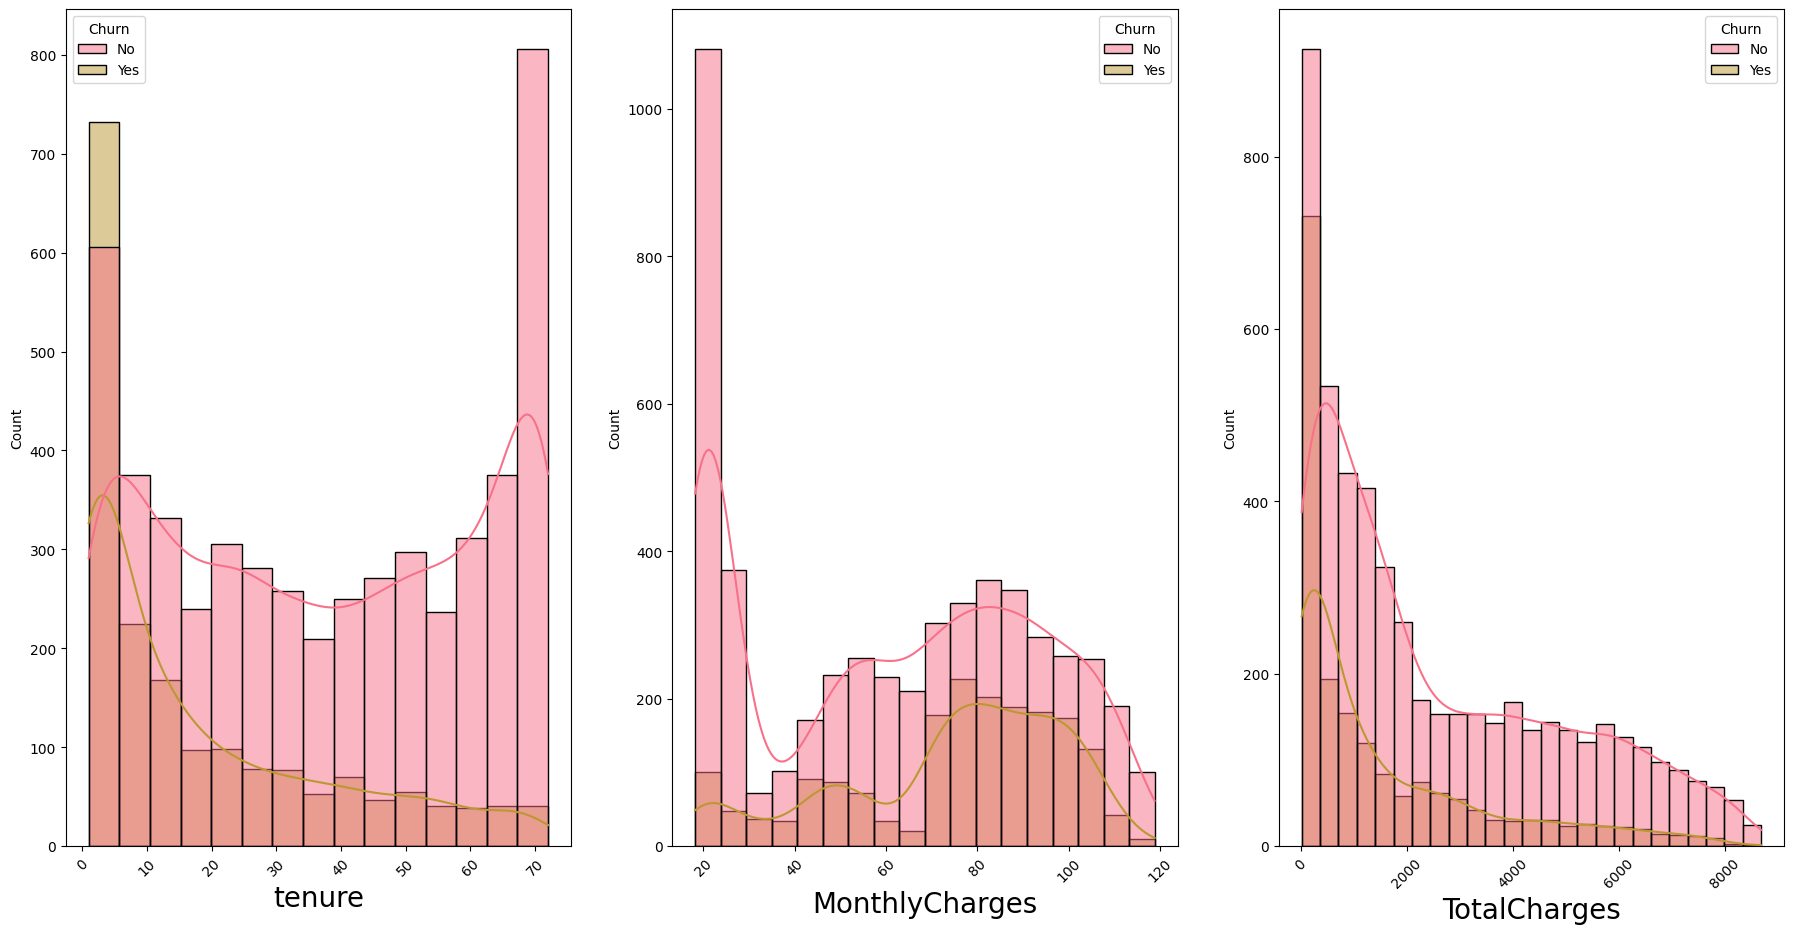

In [29]:
sns.set_palette("husl")
plt.figure(figsize=(30,50),facecolor="white")
plotnumber=1
for i in Numerical:
    if plotnumber<=3:
        ax=plt.subplot(4,4,plotnumber)
        sns.histplot(data=df,x=df[i],kde=True,hue="Churn")
        plt.xticks(rotation=45)
        plt.xlabel(i,fontsize=20)
    plotnumber=plotnumber+1
plt.show()

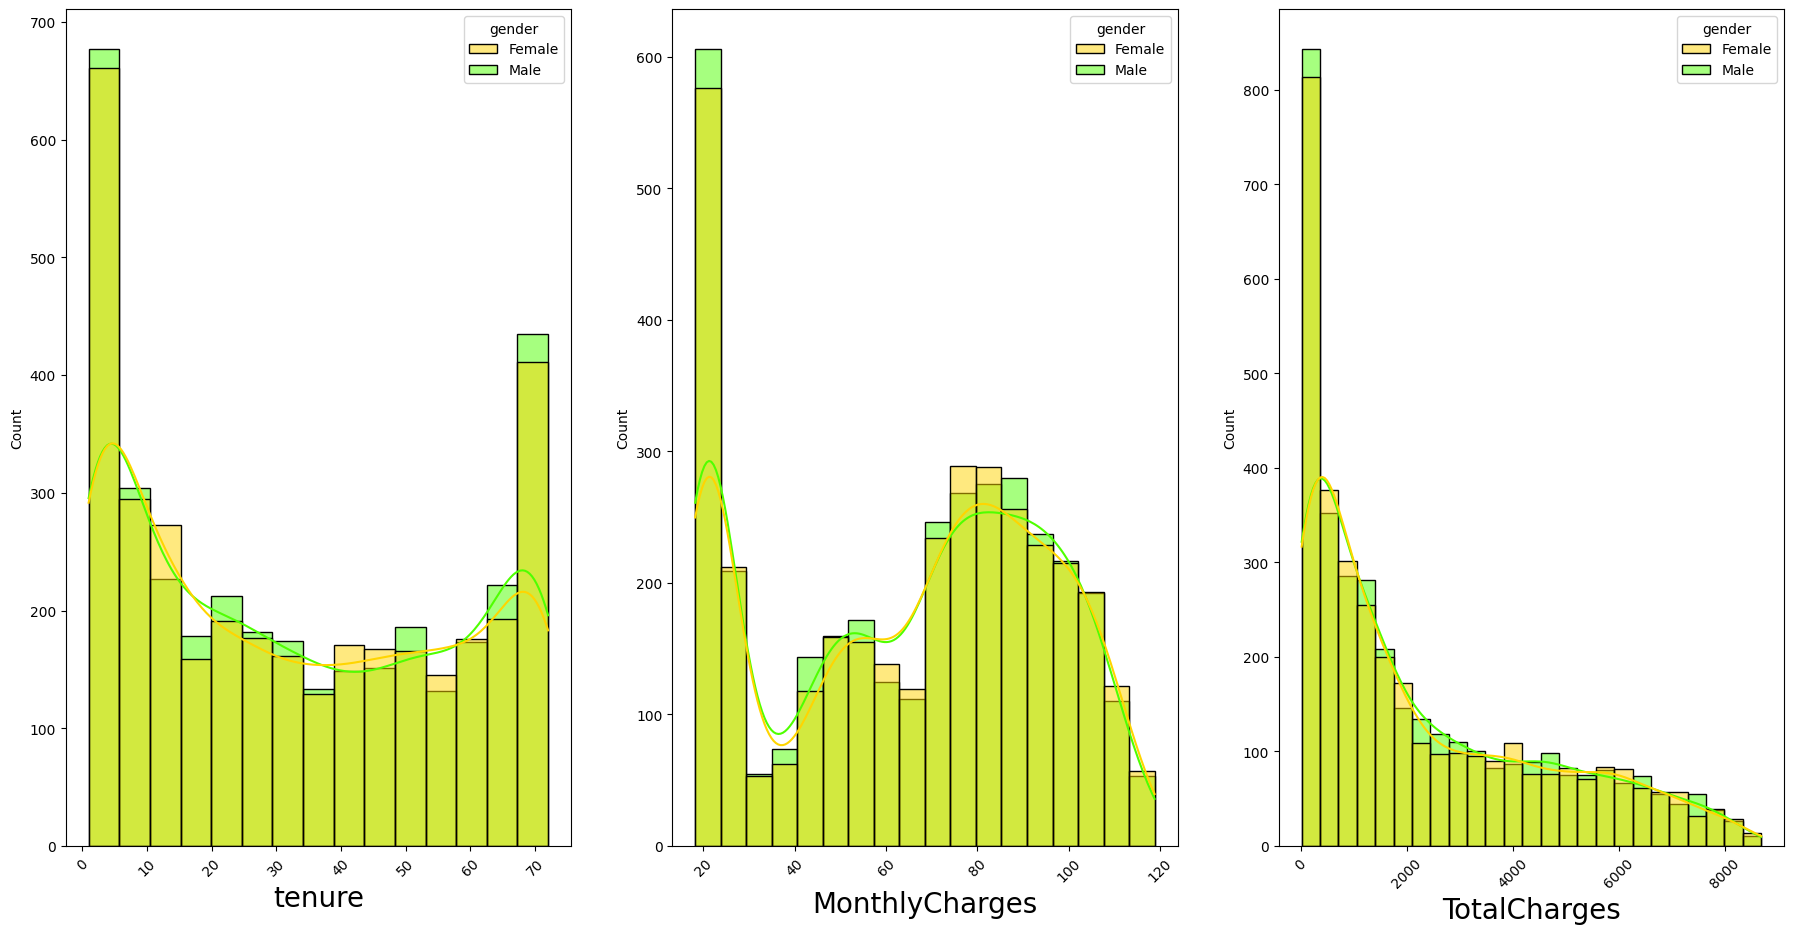

In [30]:
sns.set_palette("hsv")
plt.figure(figsize=(30,50),facecolor="white")
plotnumber=1
for i in Numerical:
    if plotnumber<=3:
        ax=plt.subplot(4,4,plotnumber)
        sns.histplot(data=df,x=df[i],kde=True,hue="gender")
        plt.xticks(rotation=45)
        plt.xlabel(i,fontsize=20)
    plotnumber=plotnumber+1
plt.show()